In [3]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [4]:
#preprocessing

df = pd.read_csv("industrial milling tool life dataset.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3462 entries, 0 to 3461
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Tool_ID                  3462 non-null   int64  
 1   Material_Type            3462 non-null   object 
 2   Spindle_Speed            3462 non-null   int64  
 3   Feed_Rate                3462 non-null   float64
 4   Cutting_Depth            3462 non-null   float64
 5   Coolant_Condition        3462 non-null   object 
 6   Vibration_X              3462 non-null   float64
 7   Vibration_Y              3462 non-null   float64
 8   Acoustic_Signal          3462 non-null   float64
 9   Spindle_Load             3462 non-null   float64
 10  Vib_X_Normalized         3462 non-null   float64
 11  Vib_Y_Normalized         3462 non-null   float64
 12  Acoustic_Normalized      3462 non-null   float64
 13  Spindle_Load_Normalized  3462 non-null   float64
 14  RMS_Vibration           

,Tool_ID,Spindle_Speed,Feed_Rate,Cutting_Depth,Vibration_X,Vibration_Y,Acoustic_Signal,Spindle_Load,Vib_X_Normalized,Vib_Y_Normalized,...,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13
count,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3.462000e+03,3.462000e+03,...,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000
mean,10.380994,1727.248989,0.274222,1.047932,0.021459,0.022942,-0.012201,50.053121,-1.795855e-17,-4.104811e-18,...,0.012647,0.022237,-0.013989,0.003752,0.012329,-0.019387,0.021994,0.028393,-0.000300,-0.022108
std,5.797868,711.268977,0.128068,0.555758,1.017067,0.998533,1.003544,9.638170,1.000144e+00,1.000144e+00,...,0.982566,1.006885,0.990390,1.005803,1.008983,1.018686,1.000413,1.010523,0.974219,0.992450
min,1.000000,500.000000,0.050000,0.100000,-3.635200,-3.856375,-3.655087,15.049548,-3.595818e+00,-3.885577e+00,...,-3.448043,-4.295391,-3.288157,-3.265301,-3.421380,-3.419596,-4.157734,-3.202058,-3.726141,-3.817043
25%,5.000000,1117.250000,0.164000,0.560000,-0.668692,-0.653738,-0.713620,43.416370,-6.786678e-01,-6.777718e-01,...,-0.662028,-0.667178,-0.670432,-0.663476,-0.668211,-0.701551,-0.657471,-0.667060,-0.662274,-0.696148
50%,10.000000,1695.500000,0.273000,1.030000,0.026007,0.030742,-0.015358,50.164940,4.472378e-03,7.812147e-03,...,0.031539,0.024079,-0.015556,0.010580,0.025229,-0.011705,0.014100,0.048347,0.019307,-0.029739
75%,15.000000,2334.000000,0.384000,1.550000,0.718451,0.698540,0.680025,56.427289,6.853951e-01,6.766879e-01,...,0.682353,0.720477,0.655672,0.667293,0.696232,0.691264,0.696102,0.715275,0.662207,0.622549
max,20.000000,2998.000000,0.500000,2.000000,4.479084,3.942331,3.611350,82.153742,4.383458e+00,3.925713e+00,...,3.295904,3.536532,3.380614,3.401876,3.745379,3.471549,3.451858,3.495113,3.446213,3.536048


In [5]:
df.isnull()
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [6]:
df=df.drop(['Tool_ID','Vib_X_Normalized',
       'Vib_Y_Normalized', 'Acoustic_Normalized', 'Spindle_Load_Normalized',
       'RMS_Vibration', 'Kurtosis_Vibration', 'Spectral_Centroid',
       'Energy_SpindleLoad',
       'MFCC_1', 'MFCC_2', 'MFCC_3', 'MFCC_4', 'MFCC_5', 'MFCC_6', 'MFCC_7',
       'MFCC_8', 'MFCC_9', 'MFCC_10', 'MFCC_11', 'MFCC_12', 'MFCC_13'],axis=1)

In [7]:
#garbage val
for i in df.select_dtypes(include='object').columns:
    print(df[i].value_counts())
    print("***"*10)

Material_Type
Titanium    1166
Steel       1162
Aluminum    1134
Name: count, dtype: int64
******************************
Coolant_Condition
OFF    1757
ON     1705
Name: count, dtype: int64
******************************


In [8]:
#EDA (exploratory data analysis)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Spindle_Speed,3462.0,1727.248989,711.268977,500.000000,1117.250000,1695.500000,2334.000000,2998.000000
Feed_Rate,3462.0,0.274222,0.128068,0.050000,0.164000,0.273000,0.384000,0.500000
Cutting_Depth,3462.0,1.047932,0.555758,0.100000,0.560000,1.030000,1.550000,2.000000
Vibration_X,3462.0,0.021459,1.017067,-3.635200,-0.668692,0.026007,0.718451,4.479084
Vibration_Y,3462.0,0.022942,0.998533,-3.856375,-0.653738,0.030742,0.698540,3.942331
Acoustic_Signal,3462.0,-0.012201,1.003544,-3.655087,-0.713620,-0.015358,0.680025,3.611350
Spindle_Load,3462.0,50.053121,9.638170,15.049548,43.416370,50.164940,56.427289,82.153742
Tool_Wear_Level,3462.0,49.975378,29.038361,0.000000,24.824413,50.292361,74.978000,100.000000
RUL,3462.0,50.114643,29.228313,0.000000,24.912938,49.553098,75.465344,100.000000
Failure_Flag,3462.0,0.197863,0.398445,0.000000,0.000000,0.000000,0.000000,1.000000


In [9]:
df.head()

,Material_Type,Spindle_Speed,Feed_Rate,Cutting_Depth,Coolant_Condition,Vibration_X,Vibration_Y,Acoustic_Signal,Spindle_Load,Tool_Wear_Level,RUL,Failure_Flag
0,Aluminum,2065,0.175,0.89,ON,0.263888,-0.813972,-0.934485,67.416607,0.000000,97.283429,0
1,Steel,808,0.478,0.24,ON,-1.454615,-0.609903,1.375179,55.136012,0.000000,100.000000,0
2,Steel,842,0.078,0.29,ON,0.110836,-1.445610,1.873576,42.703536,8.764386,94.534191,0
3,Titanium,935,0.321,0.89,OFF,-1.426464,0.040429,-0.893419,55.830507,5.930865,100.000000,0
4,Aluminum,676,0.076,0.68,ON,0.358334,-0.772673,-0.082838,49.627188,0.000000,91.329067,0


In [10]:
df.describe(include='object')

,Material_Type,Coolant_Condition
count,3462,3462
unique,3,2
top,Titanium,OFF
freq,1166,1757


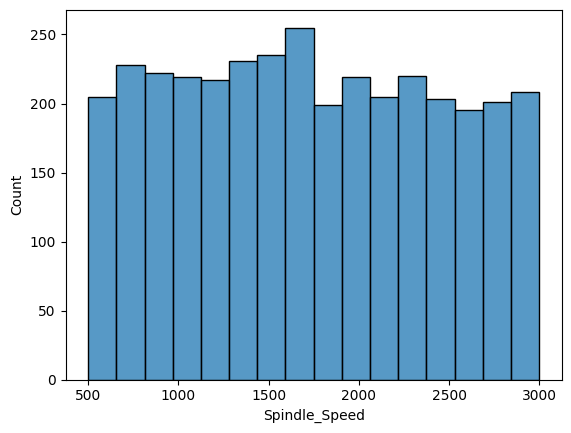

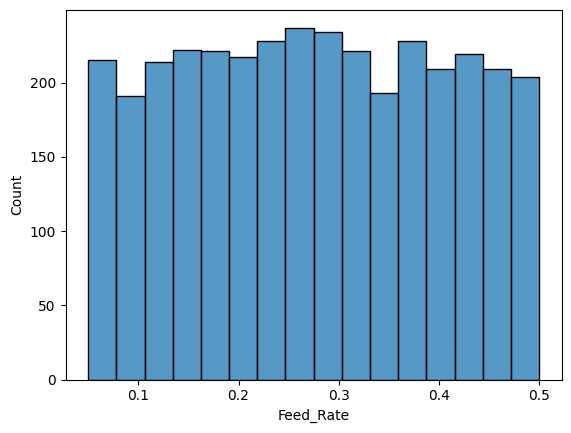

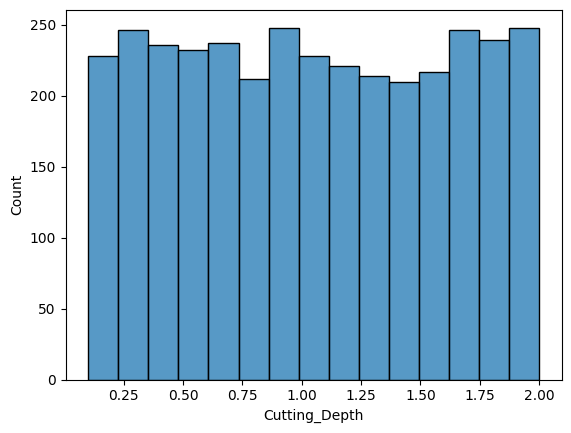

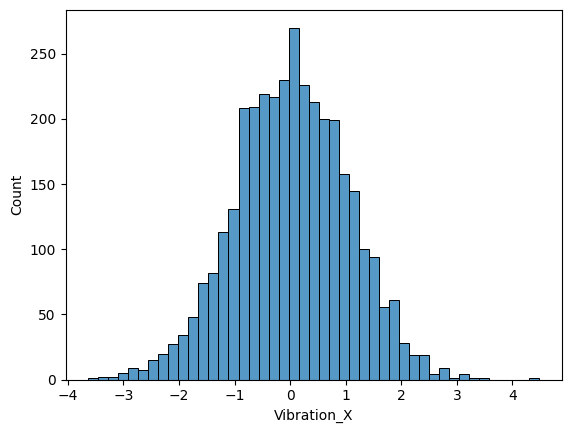

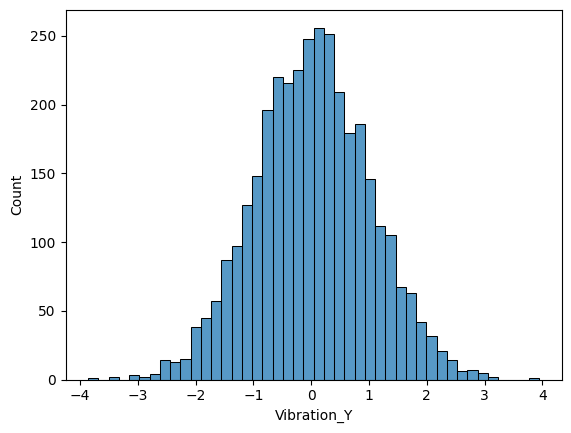

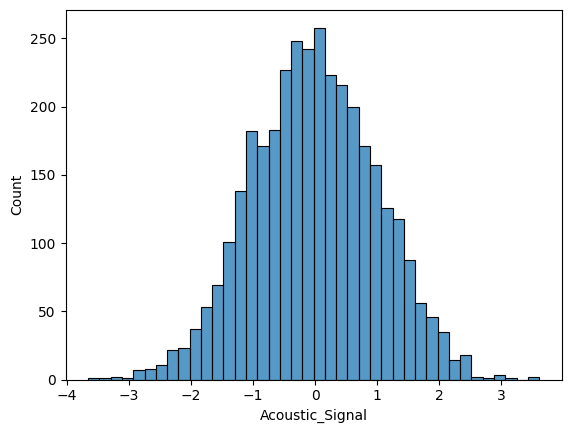

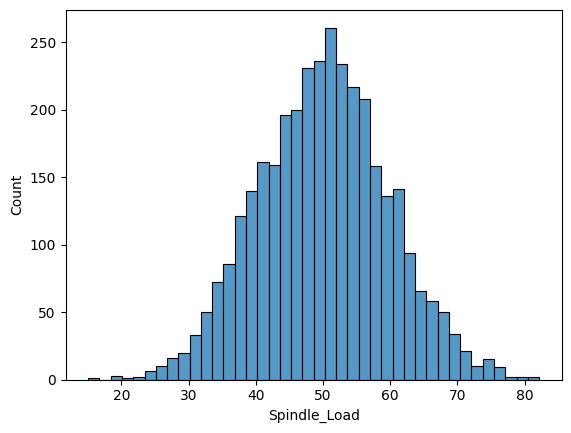

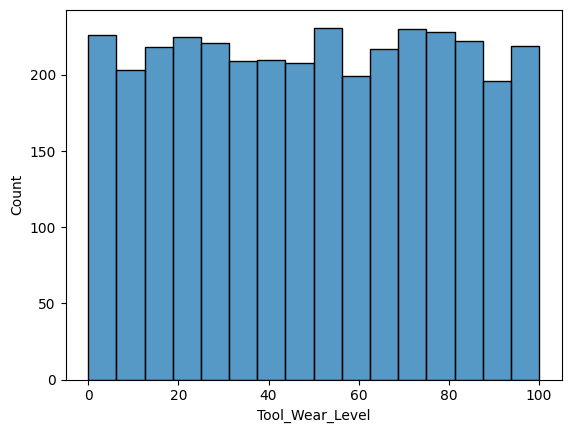

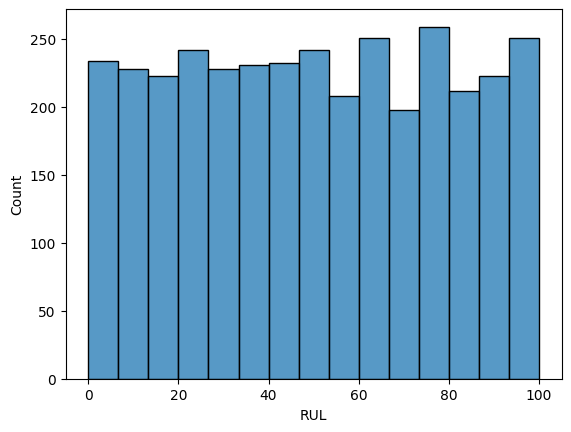

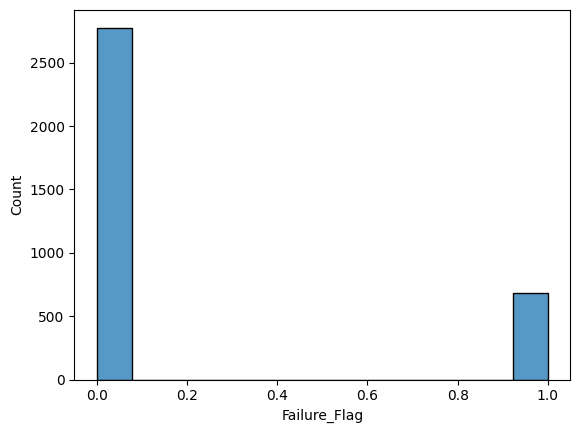

In [11]:
#histogram
for i in df.select_dtypes(include='number').columns:
    sns.histplot(data=df,x=i)
    plt.show()

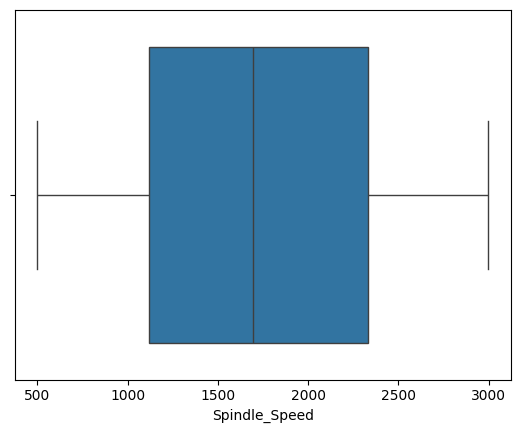

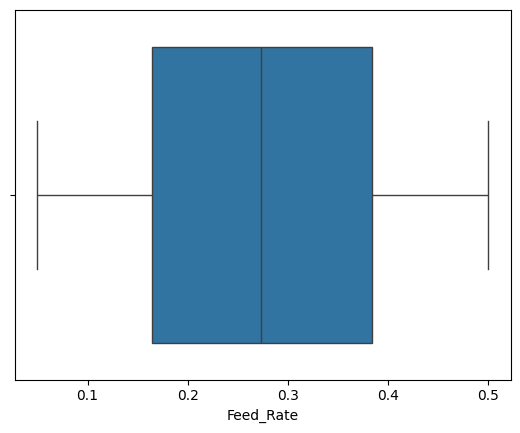

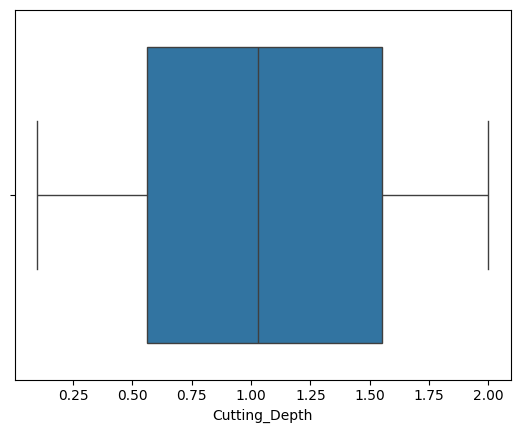

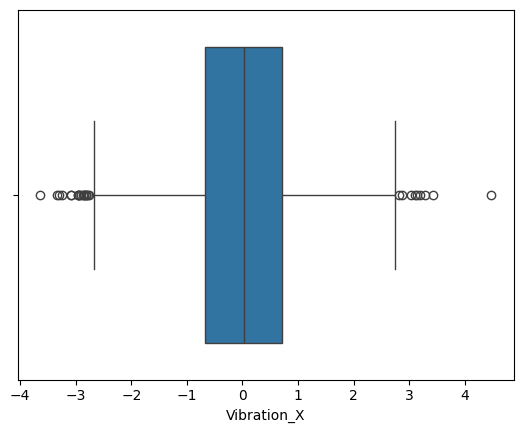

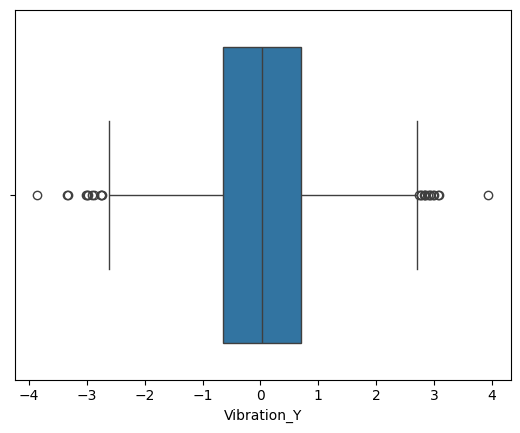

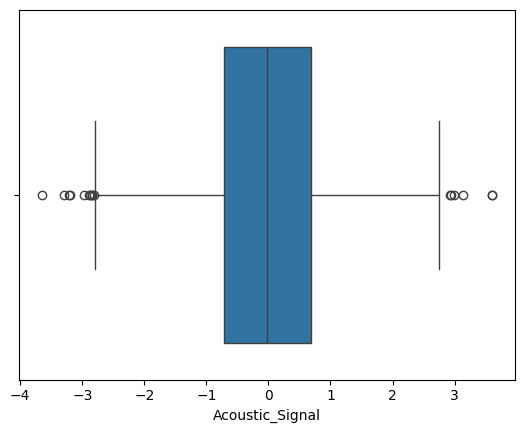

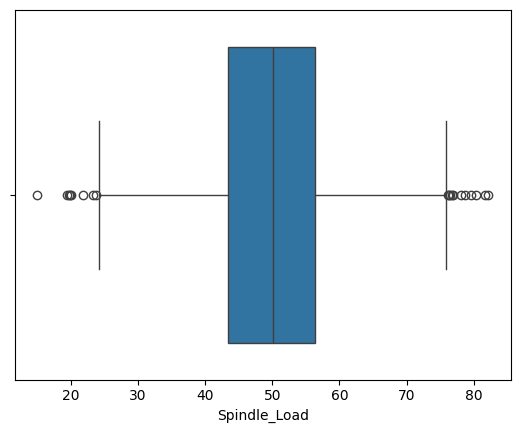

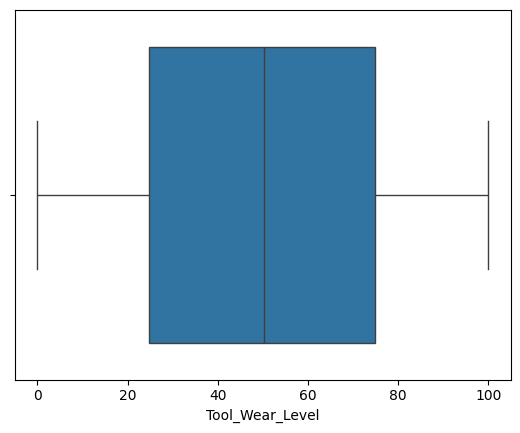

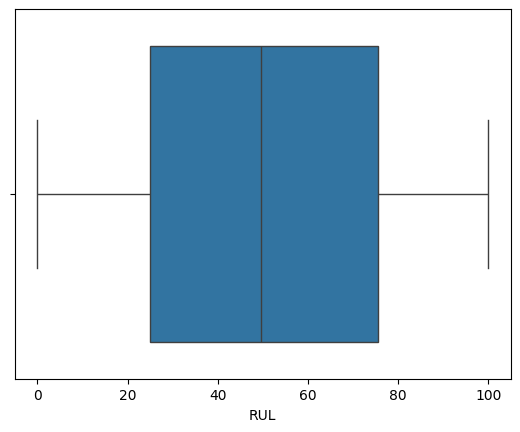

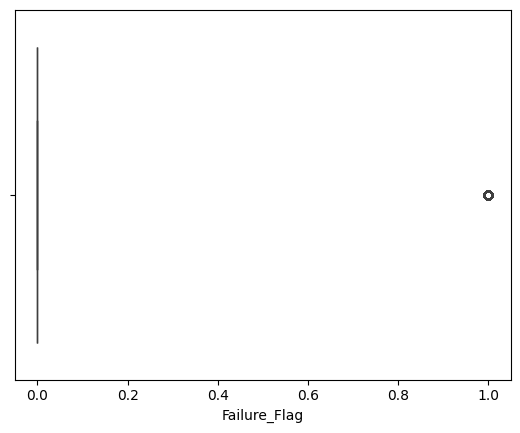

In [12]:
#box plot - outliers
for i in df.select_dtypes(include='number').columns:
    sns.boxplot(data=df,x=i)
    plt.show()

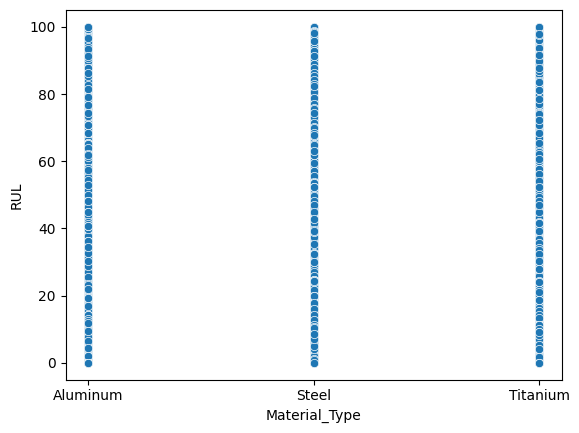

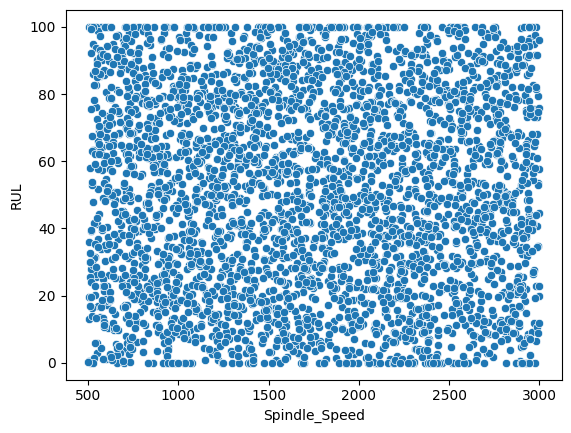

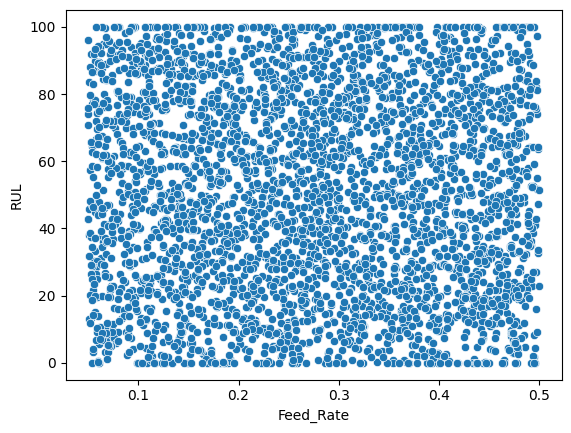

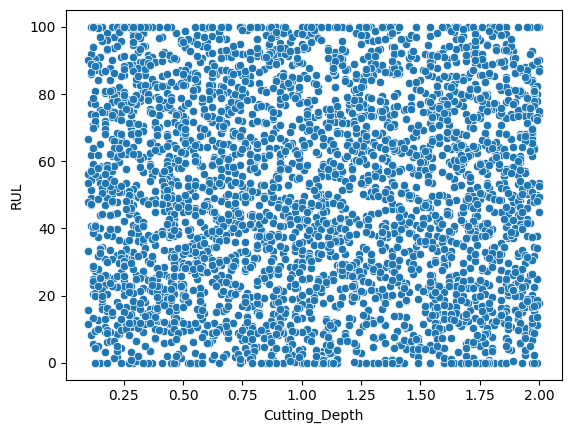

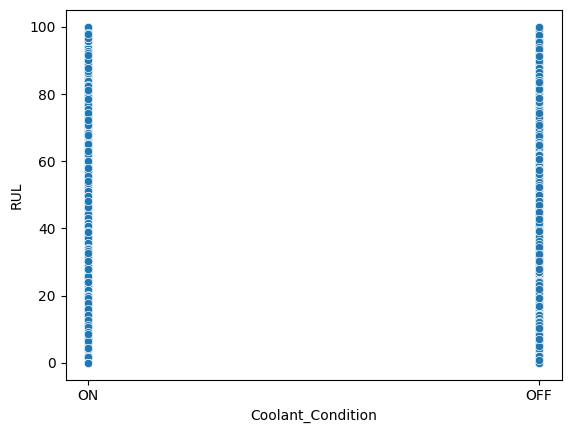

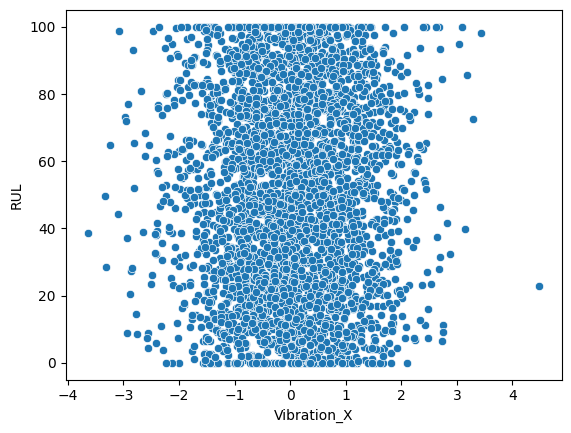

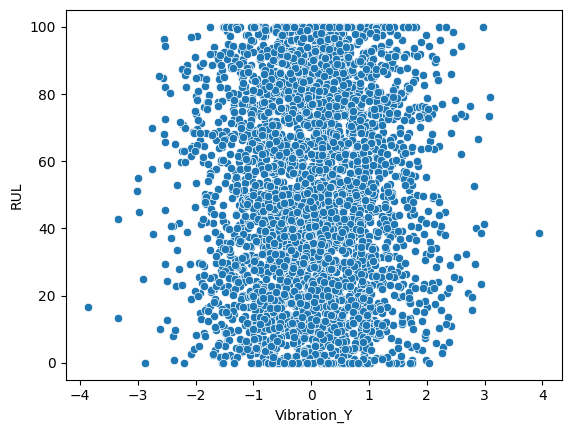

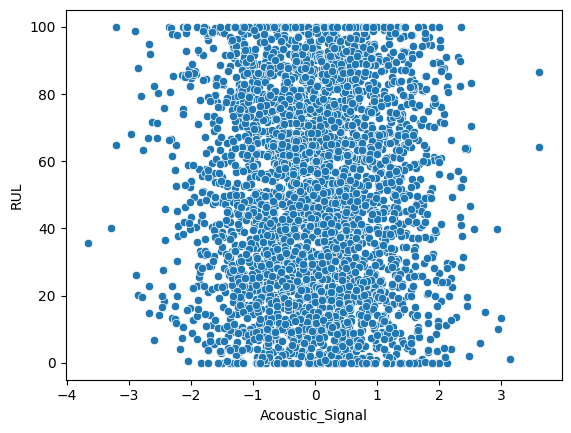

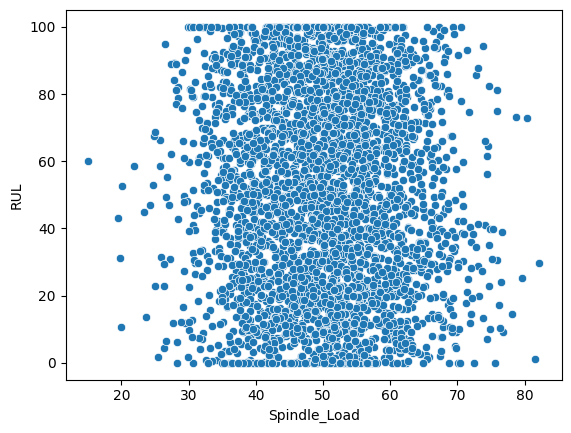

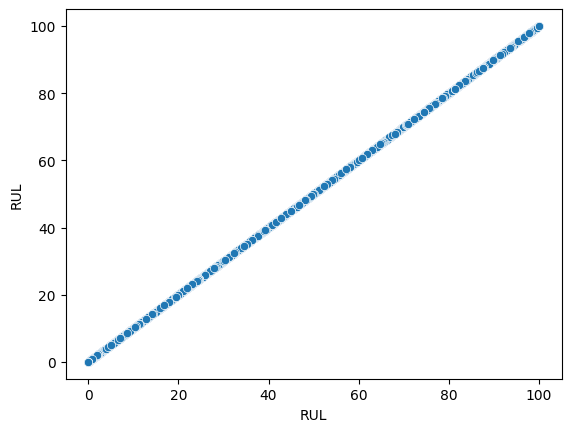

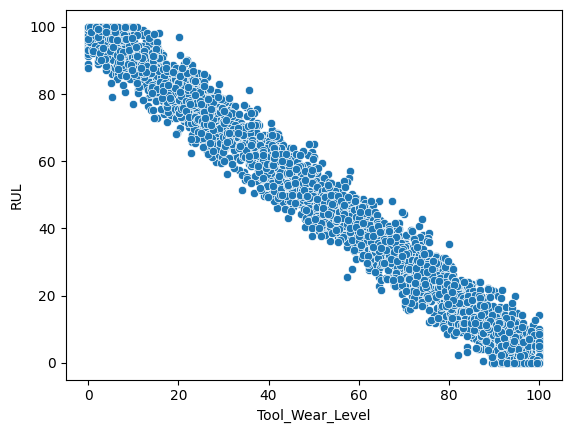

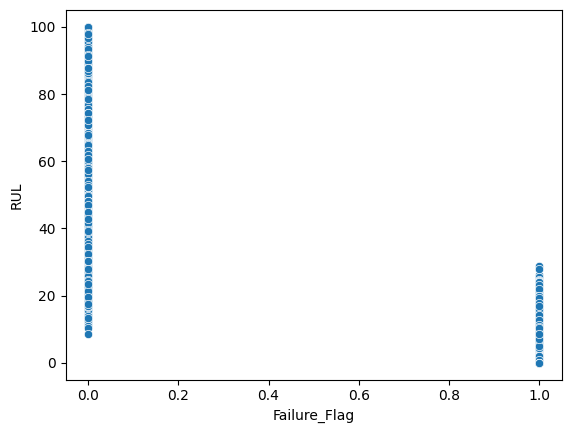

In [13]:
#scatter plt - relationship 
for i in [ 'Material_Type', 'Spindle_Speed', 'Feed_Rate',
       'Cutting_Depth', 'Coolant_Condition', 'Vibration_X', 'Vibration_Y',
       'Acoustic_Signal', 'Spindle_Load', 'RUL', 'Tool_Wear_Level', 'Failure_Flag',
       ] :
    sns.scatterplot(data=df,x=i,y='RUL')
    plt.show()


In [14]:
#correlation matrix
df_corr=df.drop(['Material_Type','Coolant_Condition'], axis=1)
corr_matrix=df_corr.corr()
print(corr_matrix)

                 Spindle_Speed  Feed_Rate  Cutting_Depth  Vibration_X  \
Spindle_Speed         1.000000  -0.000479       0.016125     0.000052   
Feed_Rate            -0.000479   1.000000       0.001593    -0.007196   
Cutting_Depth         0.016125   0.001593       1.000000    -0.006201   
Vibration_X           0.000052  -0.007196      -0.006201     1.000000   
Vibration_Y          -0.009369   0.015184       0.013523    -0.019012   
Acoustic_Signal      -0.044824  -0.018638      -0.010966     0.011281   
Spindle_Load          0.035312  -0.031728      -0.003883    -0.028474   
Tool_Wear_Level       0.004965   0.025975       0.007161    -0.006934   
RUL                  -0.005492  -0.026654      -0.008694     0.002782   
Failure_Flag          0.007545   0.012479       0.026053     0.006894   

                 Vibration_Y  Acoustic_Signal  Spindle_Load  Tool_Wear_Level  \
Spindle_Speed      -0.009369        -0.044824      0.035312         0.004965   
Feed_Rate           0.015184        

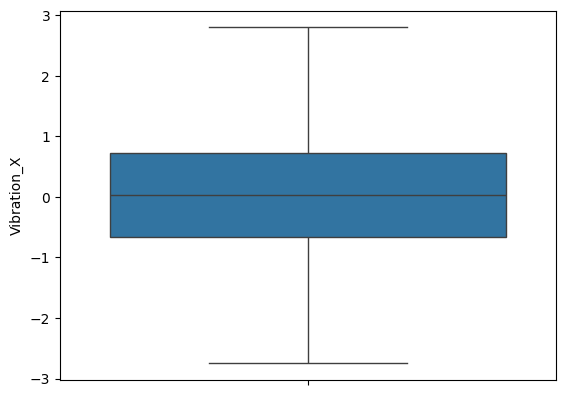

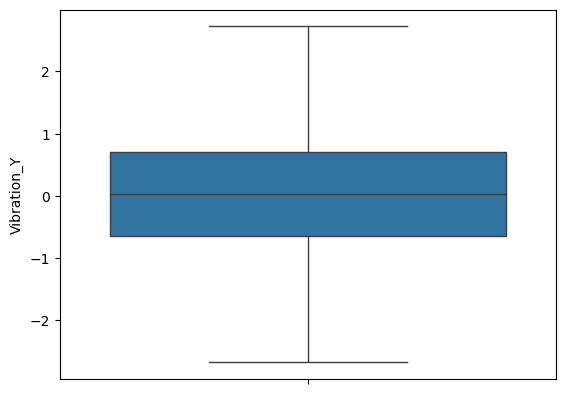

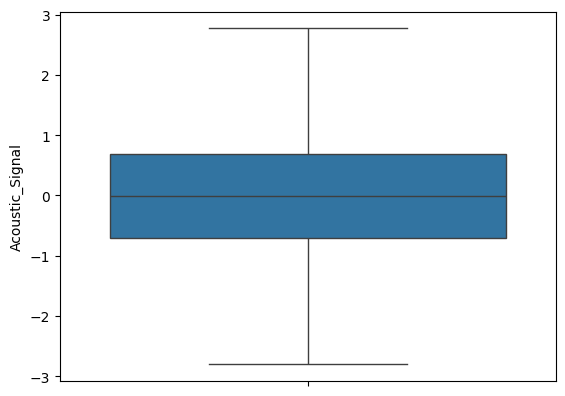

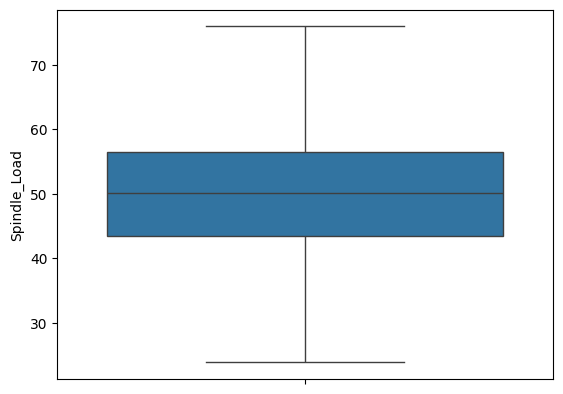

In [15]:
#outliers
def whisker(col):
    q1,q3=np.percentile(col,[25,75])
    iqr=q3-q1
    lw=q1-1.5*iqr
    uw=q3+1.5*iqr
    return lw,uw

for i in ['Vibration_X', 'Vibration_Y',
       'Acoustic_Signal', 'Spindle_Load',] :
    lw,uw=whisker(df[i])
    df[i]=np.where(df[i]<lw,lw,df[i])
    df[i]=np.where(df[i]>uw,uw,df[i])
    sns.boxplot(df[i])
    plt.show()

In [16]:
#object to numericalv val
le = LabelEncoder()
df['Material_Type_encoded'] = le.fit_transform(df['Material_Type'])
df['Coolant_Condition_encoded'] = le.fit_transform(df['Coolant_Condition'])
df.head()

,Material_Type,Spindle_Speed,Feed_Rate,Cutting_Depth,Coolant_Condition,Vibration_X,Vibration_Y,Acoustic_Signal,Spindle_Load,Tool_Wear_Level,RUL,Failure_Flag,Material_Type_encoded,Coolant_Condition_encoded
0,Aluminum,2065,0.175,0.89,ON,0.263888,-0.813972,-0.934485,67.416607,0.000000,97.283429,0,0,1
1,Steel,808,0.478,0.24,ON,-1.454615,-0.609903,1.375179,55.136012,0.000000,100.000000,0,1,1
2,Steel,842,0.078,0.29,ON,0.110836,-1.445610,1.873576,42.703536,8.764386,94.534191,0,1,1
3,Titanium,935,0.321,0.89,OFF,-1.426464,0.040429,-0.893419,55.830507,5.930865,100.000000,0,2,0
4,Aluminum,676,0.076,0.68,ON,0.358334,-0.772673,-0.082838,49.627188,0.000000,91.329067,0,0,1


In [17]:
#random forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
X=df.drop(['RUL','Material_Type','Coolant_Condition','Failure_Flag'],axis=1)
Y=df[['RUL','Failure_Flag']]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
#fitting
rand=Pipeline([
    ('scaler',StandardScaler()),
    ('random_forest',RandomForestRegressor(n_estimators=100))
])
rand.fit(X_train,Y_train)
#prediction
pred=rand.predict(X_test)
#metrics
from sklearn.metrics import r2_score
r2= r2_score(Y_test,pred)
print('r2 error : ',r2)

r2 error :  0.9752320412896232


In [18]:
#k-fold test
from sklearn.model_selection import KFold, cross_val_score
kf=KFold(n_splits=5,shuffle=True,random_state=42)
score=cross_val_score(rand,X,Y,cv=kf)
print("Accuaracy of each fold : ",score)


Accuaracy of each fold :  [0.97415554 0.97725914 0.97907771 0.97150567 0.97803098]


In [19]:
import joblib
joblib.dump(rand,"RUL_pred.pkl")
joblib.dump(r2,"r2.pkl")
joblib.dump(score,"kfold.pkl")

['kfold.pkl']

In [20]:
from sklearn.metrics import root_mean_squared_error, root_mean_squared_log_error, mean_absolute_error
rmse=root_mean_squared_error(Y_test,pred)
rmse_log=root_mean_squared_log_error(Y_test,pred)
mae=mean_absolute_error(Y_test,pred)
print(rmse,rmse_log,mae)

2.630536848394606 0.20438957679924438 2.0850268701887504


In [21]:
joblib.dump(rmse,"rmse.pkl")
joblib.dump(rmse_log,"rmse_log.pkl")
joblib.dump(mae,"mae.pkl")
joblib.dump(Y_test,"y_test.pkl")
joblib.dump(pred,"pred.pkl")

['pred.pkl']